In [2]:
import os
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import warnings
warnings.filterwarnings("ignore")

### Path visualization

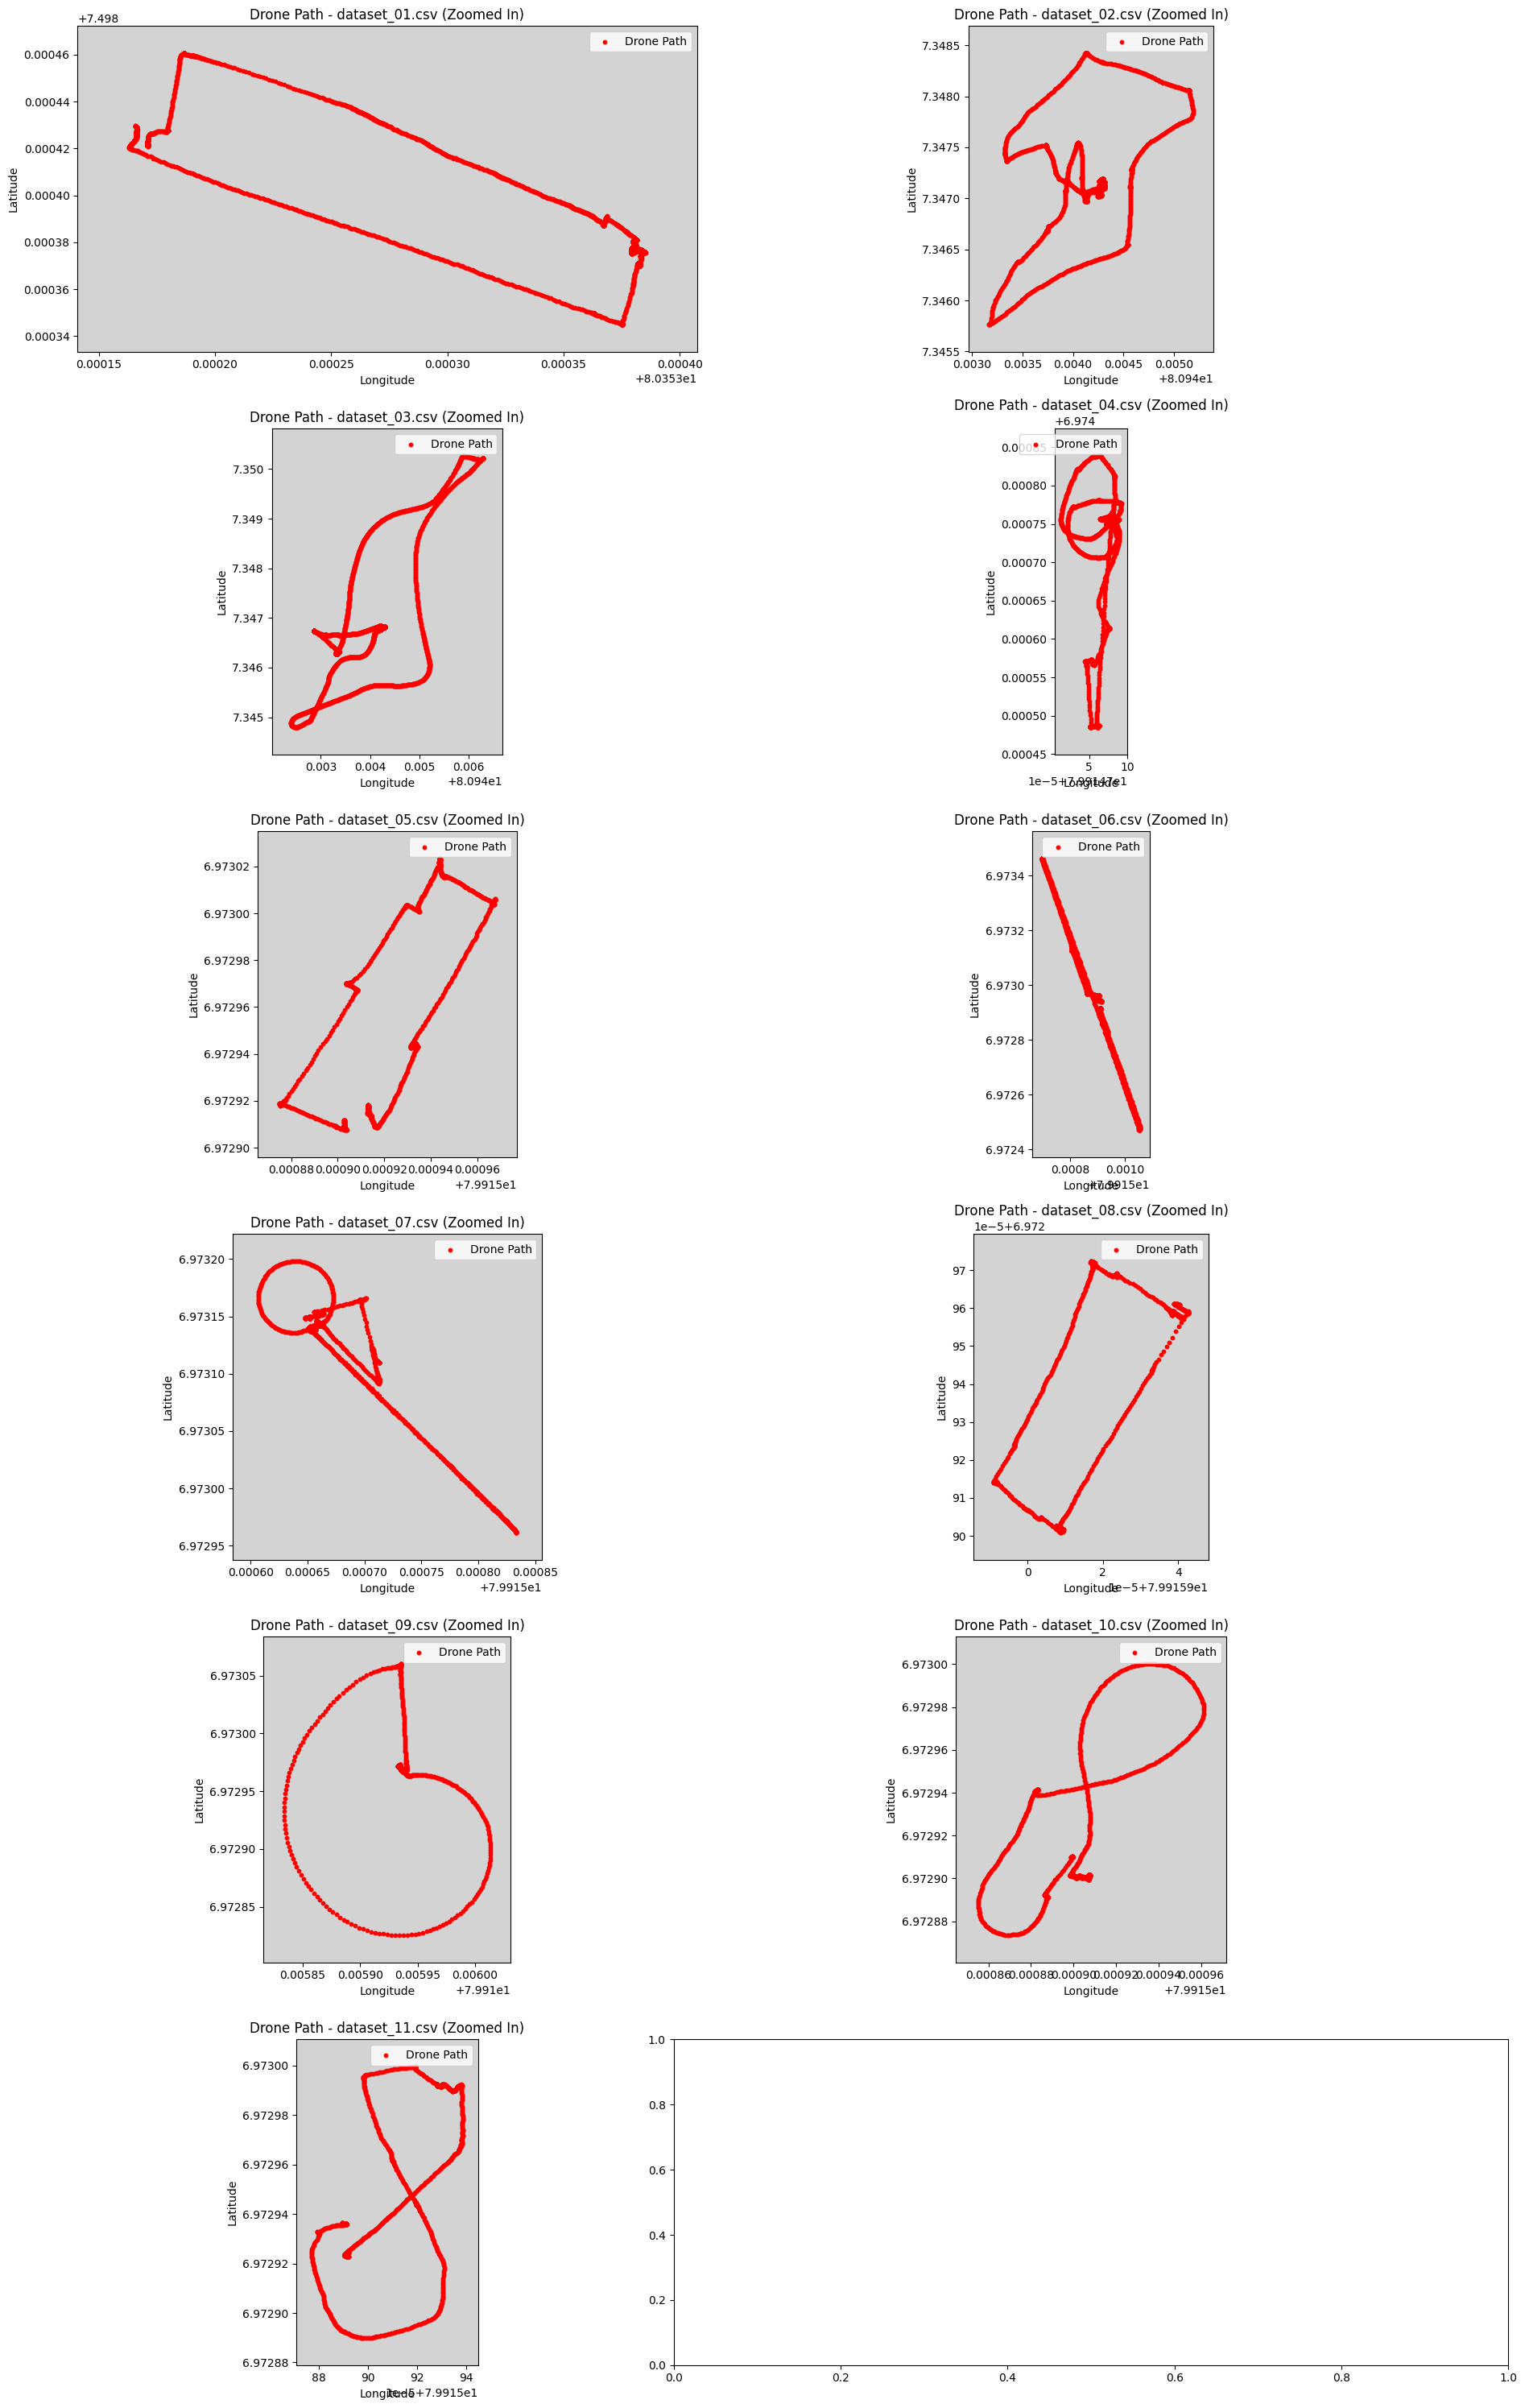

In [4]:
# Set the figure size
plt.rcParams['figure.figsize'] = [20, 12]

# Get the current working directory
current_path = os.getcwd()

# Create a subplot with rows and columns for the CSV files
num_rows = 6  # Adjust the number of rows as needed
num_cols = 2  # Adjust the number of columns as needed

# Get the list of CSV files in the current directory
csv_files = [filename for filename in os.listdir(current_path) if filename.endswith('.csv')]

# Create subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 30)) 

# Flatten the subplot array for easy iteration
axs = axs.flatten()

# Iterate through CSV files and plot on subplots
for i, filename in enumerate(csv_files):
    # Read CSV file into a DataFrame with explicit data types
    dtypes = {'OSD.longitude': 'float', 'OSD.latitude': 'float'}
    df = pd.read_csv(os.path.join(current_path, filename), dtype=dtypes)

    # Check if 'OSD.longitude' and 'OSD.latitude' columns exist
    if 'OSD.longitude' in df.columns and 'OSD.latitude' in df.columns:
        # Create a GeoDataFrame from the DataFrame with latitude and longitude
        geometry = [Point(xy) for xy in zip(df['OSD.longitude'], df['OSD.latitude'])]
        geo_df = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")  # Specify the CRS (Coordinate Reference System)

        # Get the current subplot
        ax = axs[i]

        # Get the bounding box of the drone path
        minx, miny, maxx, maxy = geo_df.geometry.total_bounds

        # Set the buffer for zooming (adjust as needed)
        buffer_percent = 0.1
        x_buffer = (maxx - minx) * buffer_percent
        y_buffer = (maxy - miny) * buffer_percent

        # Set the plot limits
        ax.set_xlim(minx - x_buffer, maxx + x_buffer)
        ax.set_ylim(miny - y_buffer, maxy + y_buffer)

        # Plot the world map
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        world.plot(ax=ax, color='lightgrey')

        # Plot the drone path on top of the world map
        geo_df.plot(ax=ax, marker='o', color='red', markersize=10, label='Drone Path')

        # Customize the subplot
        ax.set_title(f'Drone Path - {filename} (Zoomed In)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.legend()

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plots
plt.show()


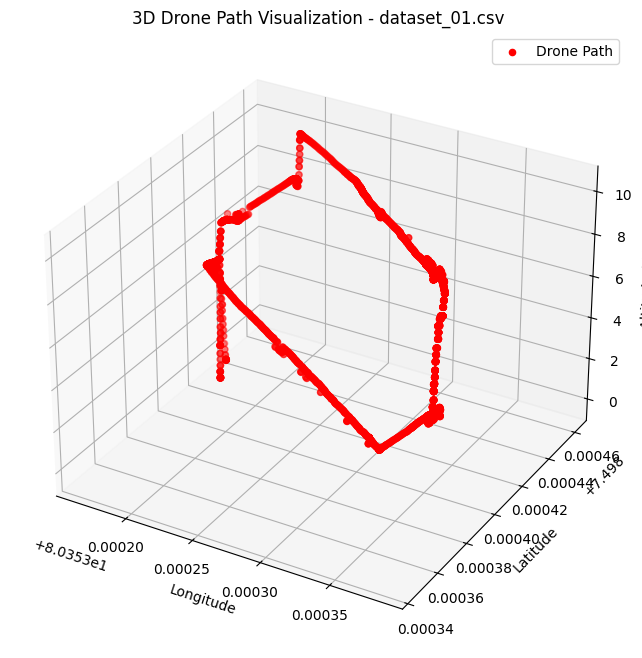

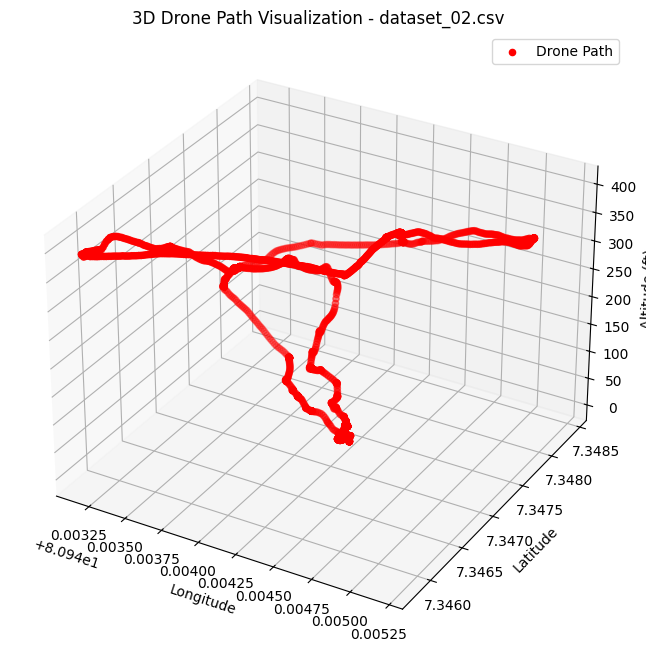

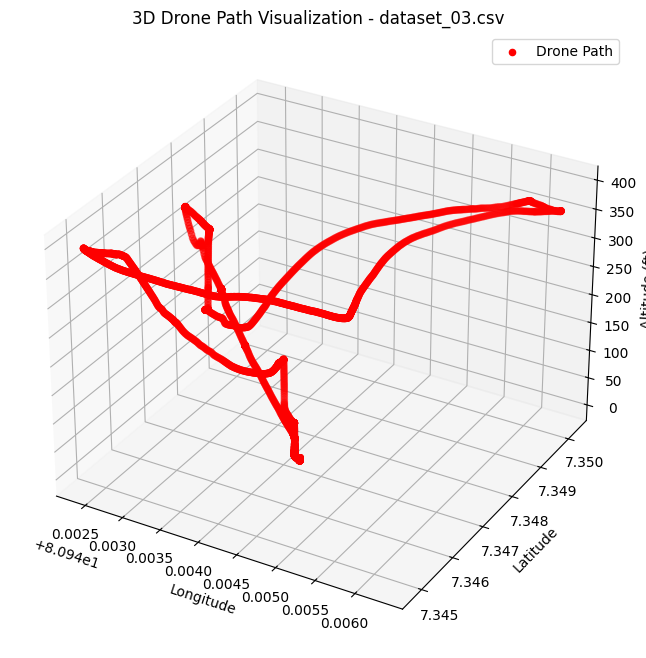

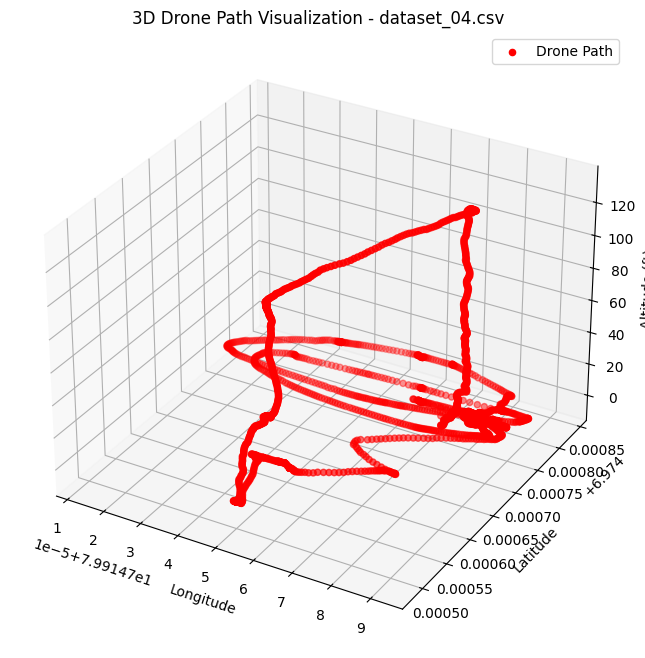

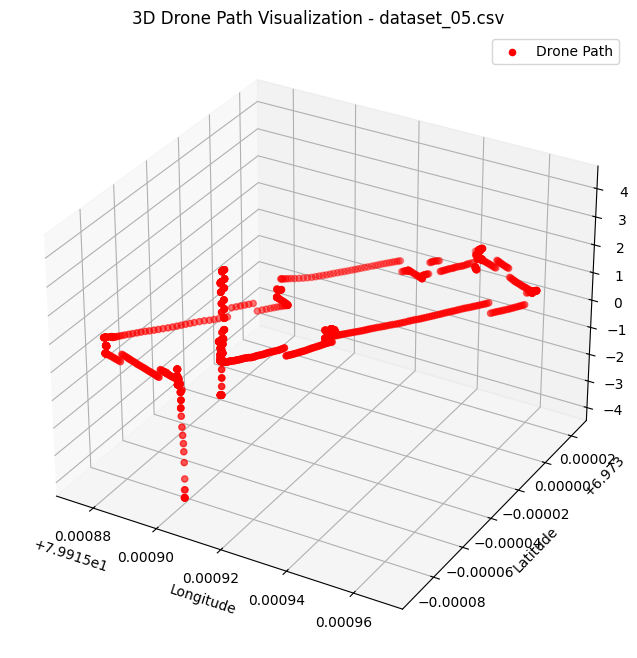

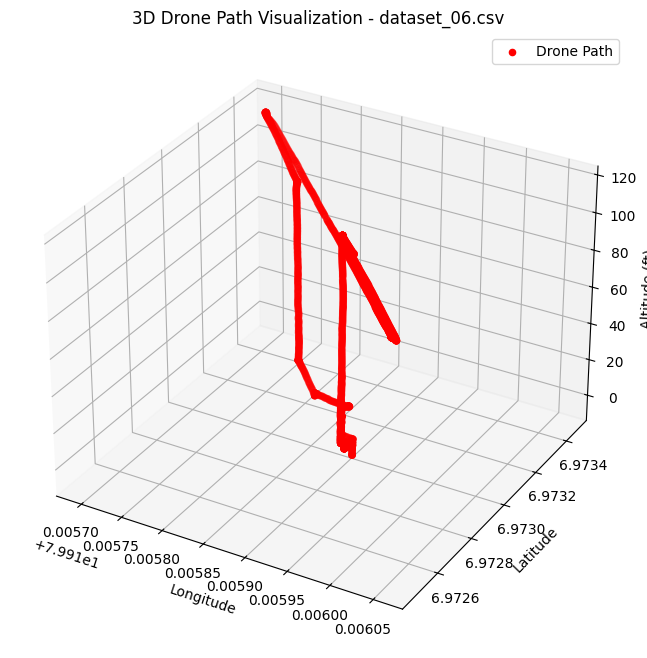

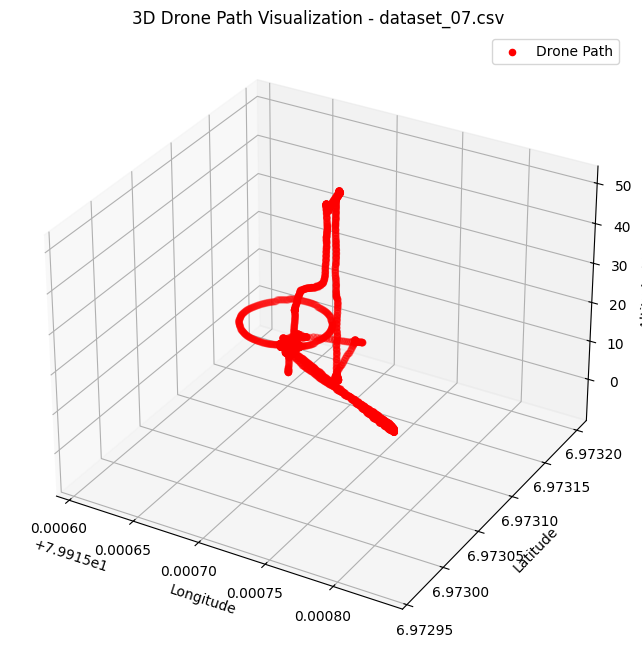

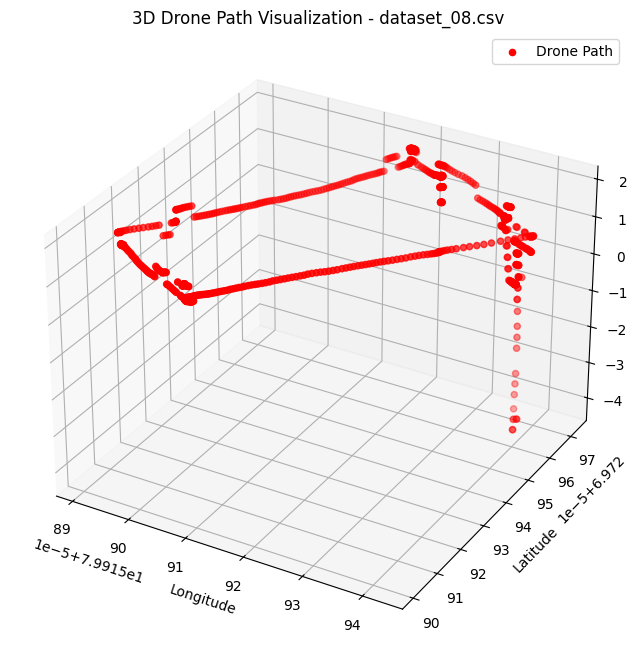

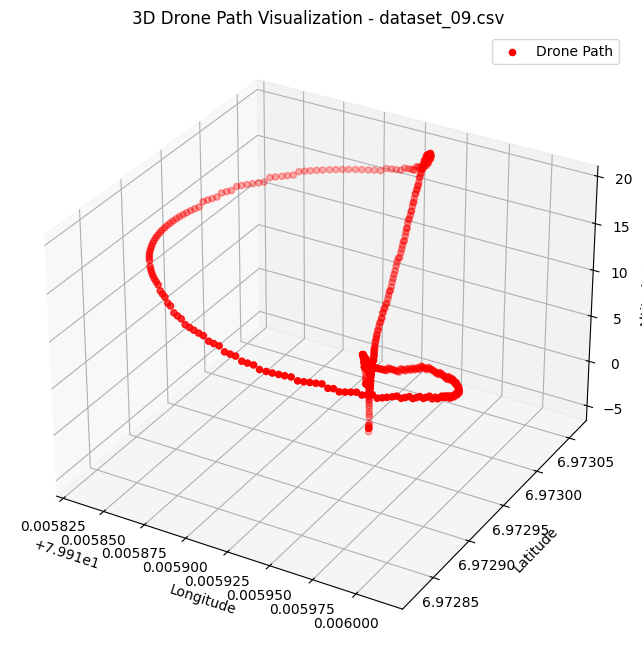

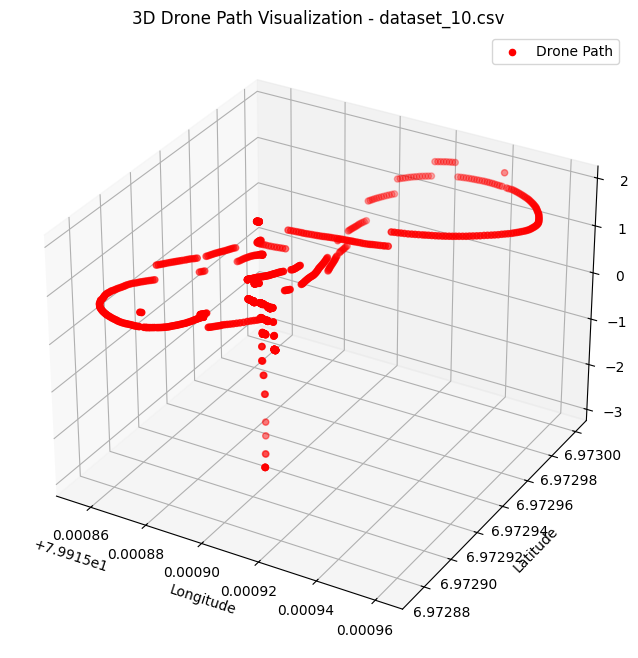

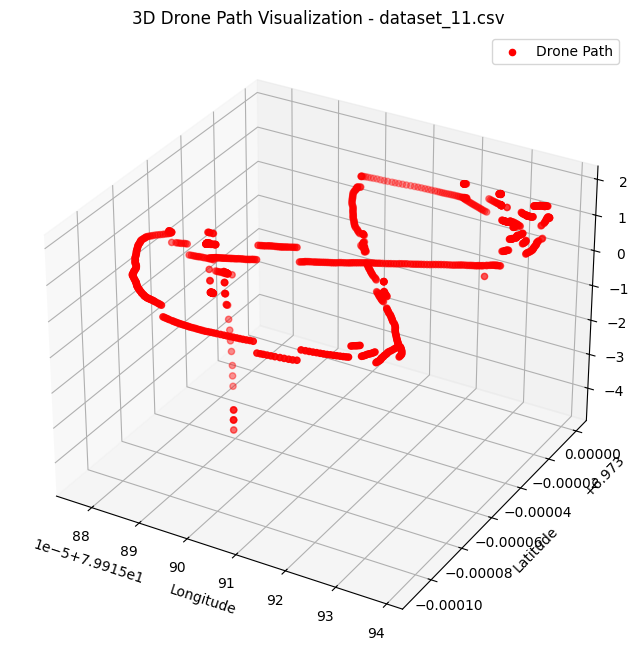

In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get the current working directory
current_path = os.getcwd()

# Iterate through all CSV files in the current directory
for filename in os.listdir(current_path):
    if filename.endswith('.csv'):
        # Read CSV file into a DataFrame with explicit data types
        dtypes = {'OSD.longitude': 'float', 'OSD.latitude': 'float', 'OSD.height [ft]': 'float'}
        df = pd.read_csv(os.path.join(current_path, filename), dtype=dtypes)

        # Create a 3D plot
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plot the drone path
        ax.scatter(df['OSD.longitude'], df['OSD.latitude'], df['OSD.height [ft]'], c='red', marker='o', label='Drone Path')

        # Customize the plot
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_zlabel('Altitude (ft)')
        ax.set_title(f'3D Drone Path Visualization - {filename}')
        ax.legend()

        # Show the plot
        plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_13596\3973253060.py:57: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
C:\Users\User\AppData\Local\Temp\ipykernel_13596\3973253060.py:57: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
C:\Users\User\AppData\Local\Temp\ipykernel_13596\3973253060.py:57: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

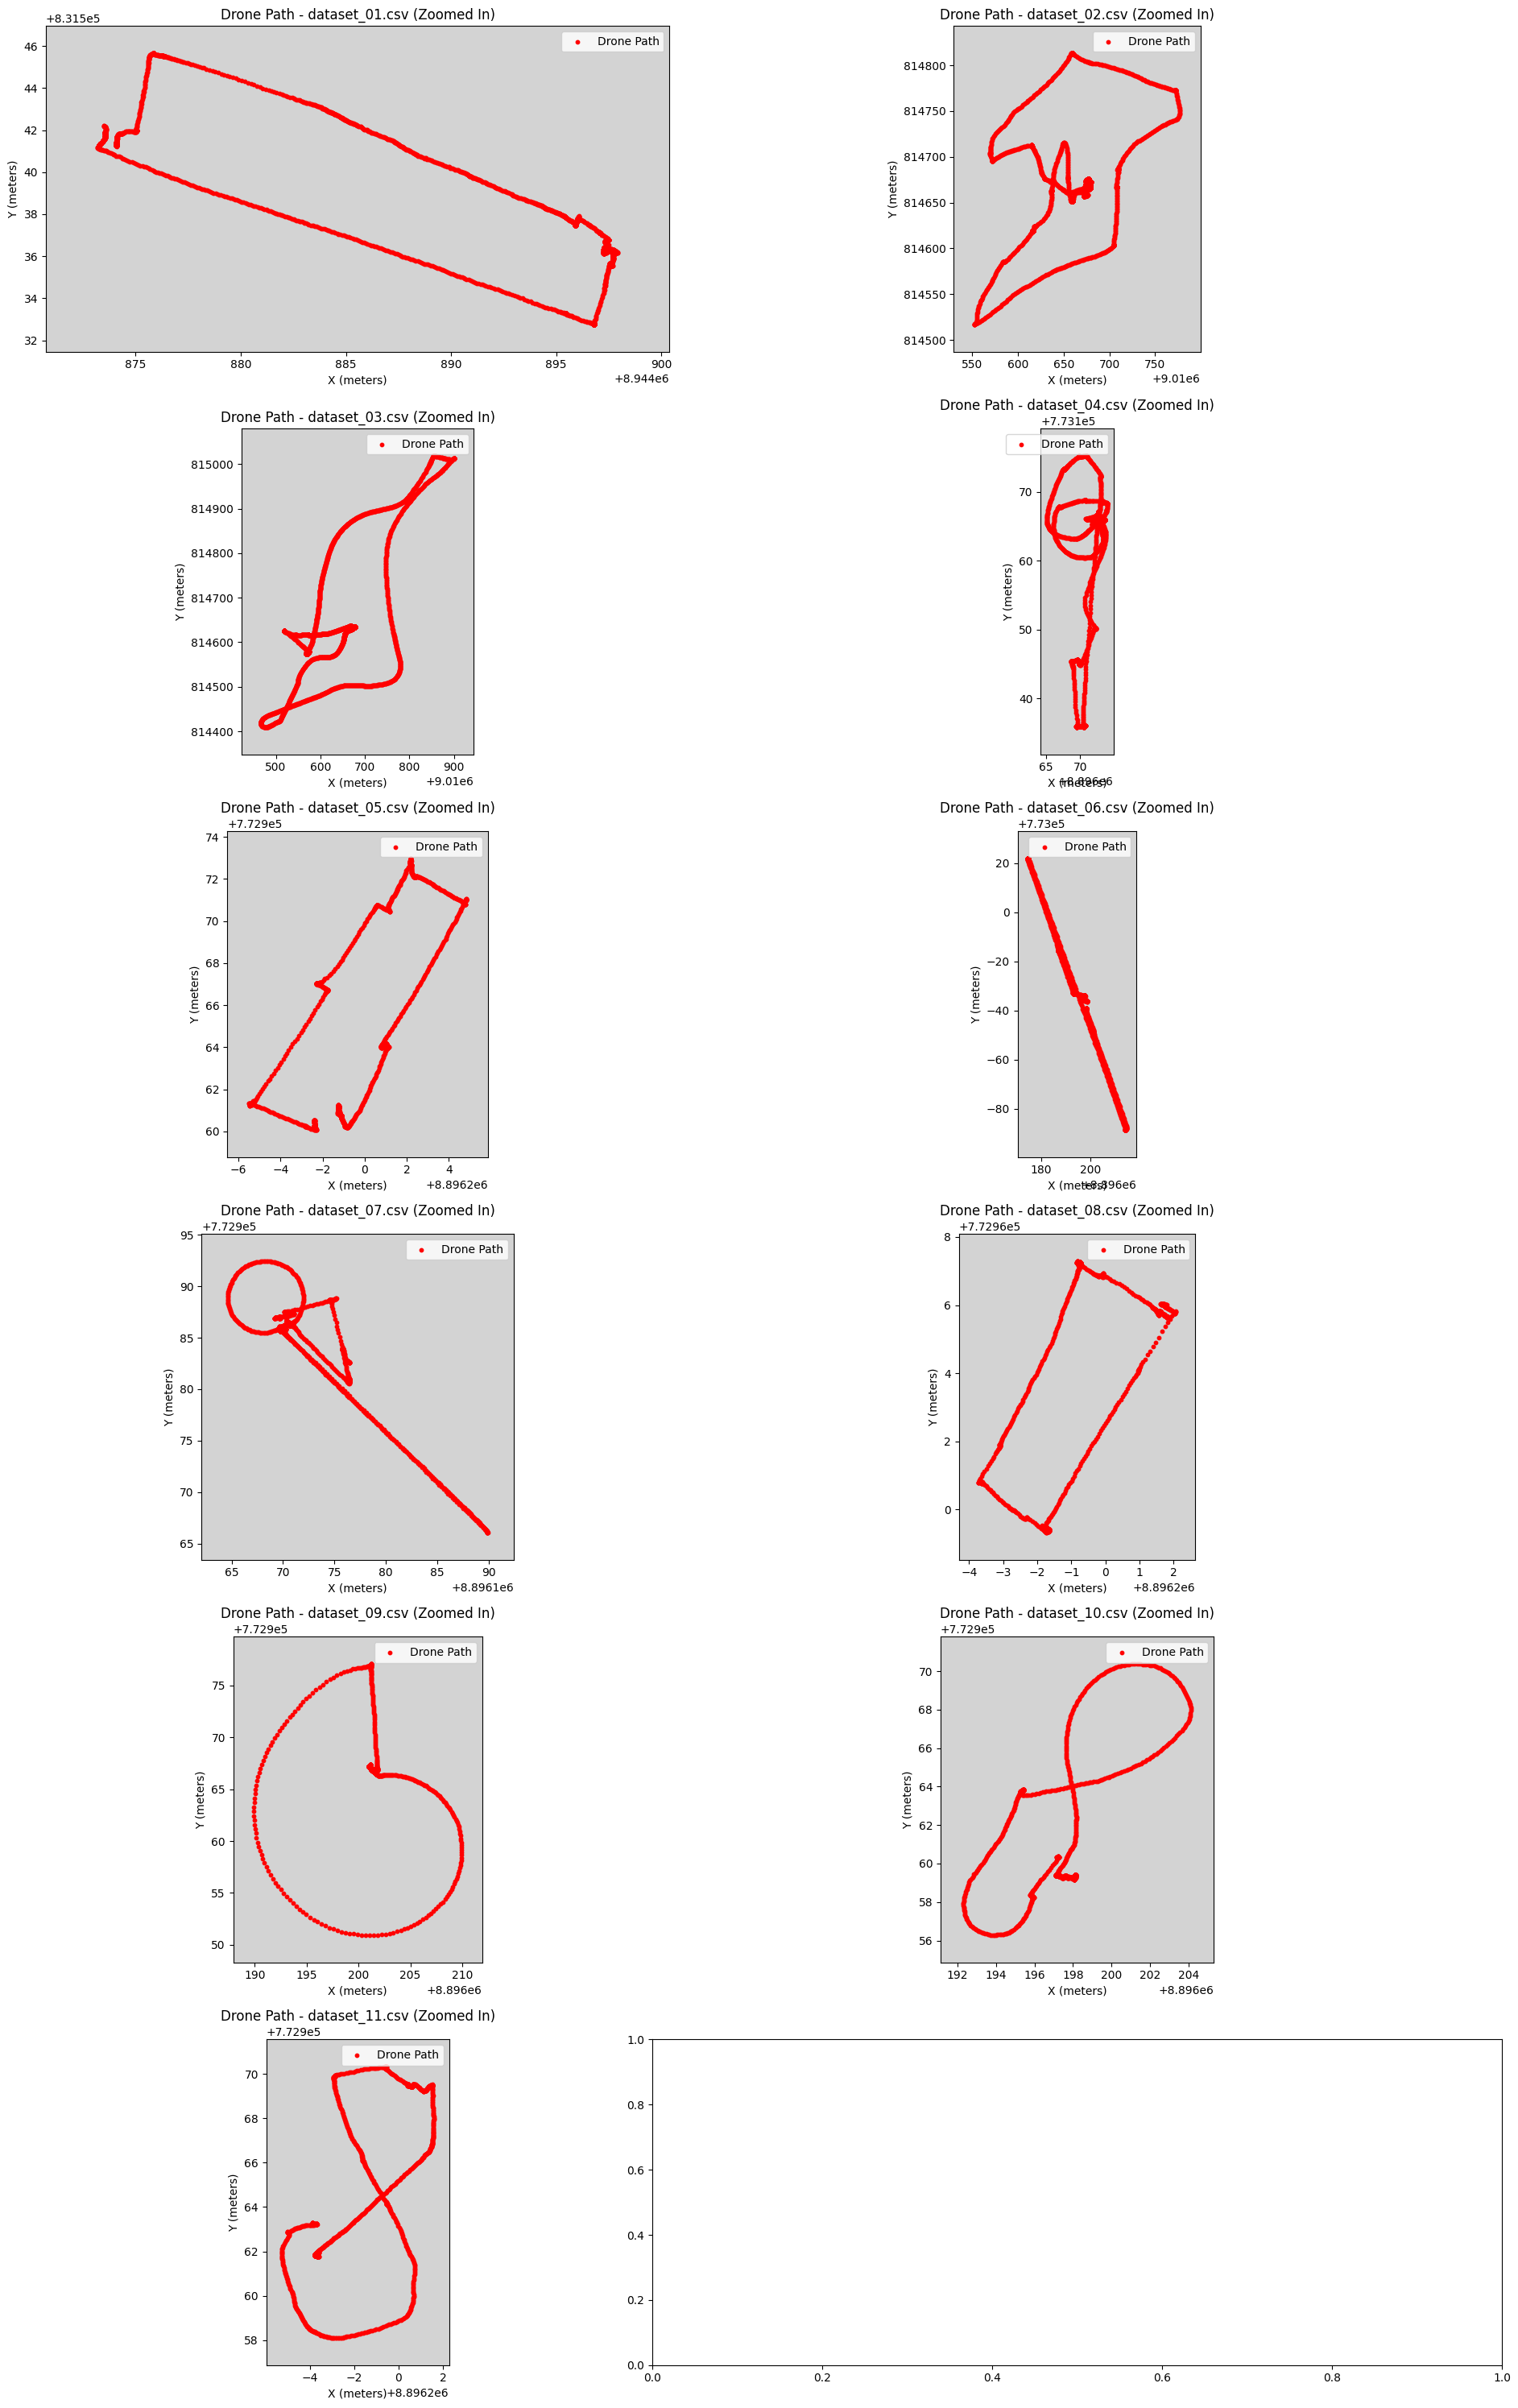

In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Set the figure size
plt.rcParams['figure.figsize'] = [20, 12]

# Get the current working directory
current_path = os.getcwd()

# Create a subplot with rows and columns for the CSV files
num_rows = 6  # Adjust the number of rows as needed
num_cols = 2  # Adjust the number of columns as needed

# Get the list of CSV files in the current directory
csv_files = [filename for filename in os.listdir(current_path) if filename.endswith('.csv')]

# Create subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 30)) 

# Flatten the subplot array for easy iteration
axs = axs.flatten()

# Iterate through CSV files and plot on subplots
for i, filename in enumerate(csv_files):
    # Read CSV file into a DataFrame with explicit data types
    dtypes = {'OSD.longitude': 'float', 'OSD.latitude': 'float'}
    df = pd.read_csv(os.path.join(current_path, filename), dtype=dtypes)

    # Check if 'OSD.longitude' and 'OSD.latitude' columns exist
    if 'OSD.longitude' in df.columns and 'OSD.latitude' in df.columns:
        # Create a GeoDataFrame from the DataFrame with latitude and longitude
        geometry = [Point(xy) for xy in zip(df['OSD.longitude'], df['OSD.latitude'])]
        geo_df = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")  # Specify the CRS (Coordinate Reference System)

        # Reproject to UTM
        geo_df = geo_df.to_crs("EPSG:3395")  # UTM projection

        # Get the current subplot
        ax = axs[i]

        # Get the bounding box of the drone path
        minx, miny, maxx, maxy = geo_df.geometry.total_bounds

        # Set the buffer for zooming (adjust as needed)
        buffer_percent = 0.1
        x_buffer = (maxx - minx) * buffer_percent
        y_buffer = (maxy - miny) * buffer_percent

        # Set the plot limits
        ax.set_xlim(minx - x_buffer, maxx + x_buffer)
        ax.set_ylim(miny - y_buffer, maxy + y_buffer)

        # Plot the world map
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        world = world.to_crs("EPSG:3395")  # UTM projection
        world.plot(ax=ax, color='lightgrey')

        # Plot the drone path on top of the world map
        geo_df.plot(ax=ax, marker='o', color='red', markersize=10, label='Drone Path')

        # Customize the subplot
        ax.set_title(f'Drone Path - {filename} (Zoomed In)')
        ax.set_xlabel('X (meters)')
        ax.set_ylabel('Y (meters)')
        ax.legend()

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plots
plt.show()
